# Week 5 Numeric Live Session — **Completed Notebook**
### The phase-space action $$S[q,p]=\int_0^T\!\big(p\dot q - H(q,p)\big)\,dt$$

**Advanced Mechanics (Fall 2026) · M. Breinig · University of Tennessee, Knoxville**

---

**What this notebook is.** This is the *reference* version of the live-session
notebook — the thing you compare against **after** you have written your own.
Every number printed below was produced by the code in the cell above it.

**What this notebook is not.** It is not a template to copy. The point of the
session is that you vary $$q$$ and $$p$$ *independently* and watch what the
formalism hands back to you. If you read the answers first, the two surprises
below stop being surprises.

**The three things you should have found:**

1. You never typed $$p = m\dot q$$ anywhere — and it came out true to machine
   precision anyway. The Legendre relation is an **output** of
   $$\partial S/\partial p=0$$, not an input.
2. The phase-space action is **never a minimum** — not for small $$T$$, not for
   any $$T$$. It is a saddle with roughly half its directions going downhill.
3. Subtract $$N$$ from the phase-space count and you recover the
   configuration-space count **exactly**, on every grid. The two formulations
   disagree about minimality and agree completely about conjugate points.

> **Reading anchor:** Scheck §2.17 (the variational principle applied to $$H$$).
> This session contains **no** time-stepping, **no** conserved-quantity tracking,
> and **no** Poisson brackets — none of it overlaps Notebook 5 or Memos 5.1/5.2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# System: the harmonic oscillator, m = omega = 1.
#
# Why harmonic?  Because S[q,p] is then an EXACT QUADRATIC FORM.  Its Hessian
# is a constant matrix, so "is this a minimum?" is answered exactly by counting
# negative eigenvalues -- no sampling, no random probing, no solver tolerance
# to argue about.  The conclusion is a theorem about the discretized problem,
# not a numerical impression.
# ---------------------------------------------------------------------------
M_MASS = 1.0
OMEGA  = 1.0

# Boundary data for Part 1 (nonzero and ASYMMETRIC on purpose: a symmetric
# choice q(T) = -q(0) would make the path odd about t = T/2, and a whole class
# of sign/indexing mistakes would cancel out and stay invisible).
QA, QB = 1.0, -0.5
T_END  = 2.0            # T = 2 < pi, so this is below the first conjugate point

H_of = lambda q, p: p**2/(2*M_MASS) + 0.5*M_MASS*OMEGA**2*q**2

print(f"m = {M_MASS},  omega = {OMEGA}")
print(f"q(0) = {QA},  q(T) = {QB},  T = {T_END}   (T/pi = {T_END/np.pi:.4f})")

m = 1.0,  omega = 1.0
q(0) = 1.0,  q(T) = -0.5,  T = 2.0   (T/pi = 0.6366)


## Part 1 — Discretizing the phase-space action

Put $$q$$ on the $$N+1$$ **nodes** $$t_k = kh$$ and $$p$$ on the $$N$$ **cell
midpoints**. That staggering is not decoration: $$\dot q$$ is naturally a
cell quantity, so pairing $$p_k$$ with $$(q_{k+1}-q_k)$$ keeps $$p\dot q$$
second-order accurate without any interpolation.

$$S_N = \sum_{k=0}^{N-1}\Big[\,p_k\,(q_{k+1}-q_k)\;-\;h\,H\big(\bar q_k,\,p_k\big)\Big],
\qquad \bar q_k=\tfrac12(q_k+q_{k+1})$$

The unknowns are $$q_1,\dots,q_{N-1}$$ (the endpoints are **fixed data**) and
$$p_0,\dots,p_{N-1}$$ — every one of which is free. **$$2N-1$$ unknowns.**

Nothing anywhere below connects $$p$$ to $$q$$. That is the whole experiment.

In [2]:
def action_phase(q, p, h):
    """S[q,p] = sum_k [ p_k (q_{k+1}-q_k) - h H(qbar_k, p_k) ].

    q : (N+1,) values on nodes, INCLUDING both fixed endpoints
    p : (N,)   values on cell midpoints -- completely independent of q
    """
    qbar = 0.5*(q[1:] + q[:-1])
    return np.sum(p*(q[1:] - q[:-1]) - h*H_of(qbar, p))


def action_config(q, h):
    """The Week-4 object, for comparison: S[q] = sum_k h [ (m/2) qdot^2 - V ]."""
    qdot = (q[1:] - q[:-1])/h
    qbar = 0.5*(q[1:] + q[:-1])
    return np.sum(h*(0.5*M_MASS*qdot**2 - 0.5*M_MASS*OMEGA**2*qbar**2))


# Sanity check: feed in the exact continuum solution and confirm both actions
# agree.  They must -- on the true path (and only there) the two functionals
# take the same value.
c1      = (QB - QA*np.cos(OMEGA*T_END))/np.sin(OMEGA*T_END)
q_exact = lambda t: QA*np.cos(OMEGA*t) + c1*np.sin(OMEGA*t)
p_exact = lambda t: M_MASS*OMEGA*(-QA*np.sin(OMEGA*t) + c1*np.cos(OMEGA*t))

# closed form:  S* = (m w / 2) [ (qA^2+qB^2) cos(wT) - 2 qA qB ] / sin(wT)
S_EXACT = 0.5*M_MASS*OMEGA*((QA**2 + QB**2)*np.cos(OMEGA*T_END)
                            - 2*QA*QB)/np.sin(OMEGA*T_END)

N = 2000; h = T_END/N
t_nodes = np.linspace(0.0, T_END, N+1)
t_mid   = 0.5*(t_nodes[1:] + t_nodes[:-1])
Sp = action_phase(q_exact(t_nodes), p_exact(t_mid), h)
Sc = action_config(q_exact(t_nodes), h)
print(f"S_phase (exact path, N={N}) = {Sp:.12f}")
print(f"S_config(exact path, N={N}) = {Sc:.12f}")
print(f"S exact  (closed form)      = {S_EXACT:.12f}")
print(f"\nS_phase - S_config = {Sp-Sc:.2e}   <- must be ~0: on the TRUE path the")
print( "                                     two functionals agree identically.")
print(f"S_phase - S_exact  = {Sp-S_EXACT:.2e}   <- NOT zero: this is the O(h^2)")
print( "                                     quadrature error of the sum, and it")
print( "                                     shrinks by 4 each time N doubles.")

S_phase (exact path, N=2000) = 0.263839197714
S_config(exact path, N=2000) = 0.263839197714
S exact  (closed form)      = 0.263839113672

S_phase - S_config = -1.05e-15   <- must be ~0: on the TRUE path the
                                     two functionals agree identically.
S_phase - S_exact  = 8.40e-08   <- NOT zero: this is the O(h^2)
                                     quadrature error of the sum, and it
                                     shrinks by 4 each time N doubles.


## Part 2 — Solve for the stationary point, and watch the momentum appear

Setting $$\partial S_N/\partial q_k = 0$$ and $$\partial S_N/\partial p_k = 0$$
gives, after dividing each equation by $$h$$ so both are $$O(1)$$:

$$\frac{p_{k-1}-p_k}{h} \;=\; \tfrac{m\omega^2}{2}\big(\bar q_{k-1}+\bar q_k\big),
\qquad\qquad
\frac{q_{k+1}-q_k}{h} \;=\; \frac{p_k}{m}$$

For the harmonic oscillator this is a **linear** system — one `np.linalg.solve`,
no Newton iteration, no initial guess, nothing to converge.

Look at the second equation. We did not impose it; we *derived* it. It says
$$p = m\dot q$$ in discrete form — the Legendre relation, delivered by the
variational principle rather than assumed by us.

In [3]:
def phase_system(N, T=T_END):
    """Assemble A x = -b for the stationary conditions.
    x = [ q_1 ... q_{N-1} , p_0 ... p_{N-1} ]   ->   2N-1 unknowns.

    The fixed endpoint values are NOT unknowns; wherever q_0 or q_N appears it
    moves to the right-hand side.  (Getting this wrong is the classic bug: if
    the endpoints leak into the unknown vector you silently solve a different
    boundary-value problem and everything still 'converges'.)
    """
    h = T/N; nq = N - 1; n = 2*N - 1
    A = np.zeros((n, n)); b = np.zeros(n)
    fixed = {0: QA, N: QB}

    def add_q(row, k, c):
        if k in fixed: b[row] += c*fixed[k]      # known -> right-hand side
        else:          A[row, k-1] += c          # unknown -> matrix

    for j in range(nq):                          # dS/dq_k = 0,  k = 1..N-1
        k = j + 1
        A[j, nq+k-1] += 1.0/h
        A[j, nq+k  ] -= 1.0/h
        add_q(j, k-1, -0.25*M_MASS*OMEGA**2)
        add_q(j, k  , -0.50*M_MASS*OMEGA**2)
        add_q(j, k+1, -0.25*M_MASS*OMEGA**2)

    for k in range(N):                           # dS/dp_k = 0,  k = 0..N-1
        r = nq + k
        add_q(r, k+1,  1.0/h)
        add_q(r, k  , -1.0/h)
        A[r, nq+k] -= 1.0/M_MASS

    return A, b, h, nq


def solve_phase(N, T=T_END):
    A, b, h, nq = phase_system(N, T)
    x = np.linalg.solve(A, -b)
    q = np.concatenate(([QA], x[:nq], [QB]))     # glue the fixed endpoints back on
    p = x[nq:]
    return q, p, h


print(f"{'N':>6} {'max|p - m dq/h|':>18} {'max|q - q_exact|':>18} {'ratio':>7} "
      f"{'S_phase':>16}")
prev = None
for N in [20, 40, 80, 160, 320, 640]:
    q, p, h = solve_phase(N)
    legendre = np.max(np.abs(p - M_MASS*(q[1:] - q[:-1])/h))
    err      = np.max(np.abs(q - q_exact(np.linspace(0.0, T_END, N+1))))
    ratio    = (prev/err) if prev else np.nan
    prev     = err
    print(f"{N:6d} {legendre:18.3e} {err:18.6e} {ratio:7.3f} "
          f"{action_phase(q, p, h):16.12f}")
print(f"\nS exact = {S_EXACT:.12f}")

     N    max|p - m dq/h|   max|q - q_exact|   ratio          S_phase
    20          2.109e-15       6.222075e-04     nan   0.264678398338
    40          5.551e-15       1.558999e-04   3.991   0.264049147605
    80          2.509e-14       3.902747e-05   3.995   0.263891635481
   160          2.887e-14       9.758236e-06   3.999   0.263852244958
   320          1.187e-13       2.439645e-06   4.000   0.263842396546
   640          5.825e-13       6.099165e-07   4.000   0.263839934394

S exact = 0.263839113672


### Read those two columns carefully — they behave completely differently

**`max|p - m dq/h|` is $$\sim\!10^{-15}$$ at $$N=20$$ and stays at roundoff.**
It is *not* converging to zero as the grid refines — it was zero from the
coarsest grid. That is the signature of an **algebraic identity**, not a
numerical approximation. The equation $$\partial S/\partial p=0$$ *is*
$$p = m\,\Delta q/h$$; the linear solver had no choice.

**`max|q - q_exact|` falls by 4.000 per doubling.** *That* is the discretization
error, and it behaves exactly like the Week 4 configuration-space solve — second
order, as the midpoint rule promises.

> **The point:** in the Hamiltonian formulation, momentum is not a definition you
> carry in from Lagrangian mechanics. It is what stationarity in the $$p$$
> direction *means*. Scheck §2.17 says this in one line; you just measured it.

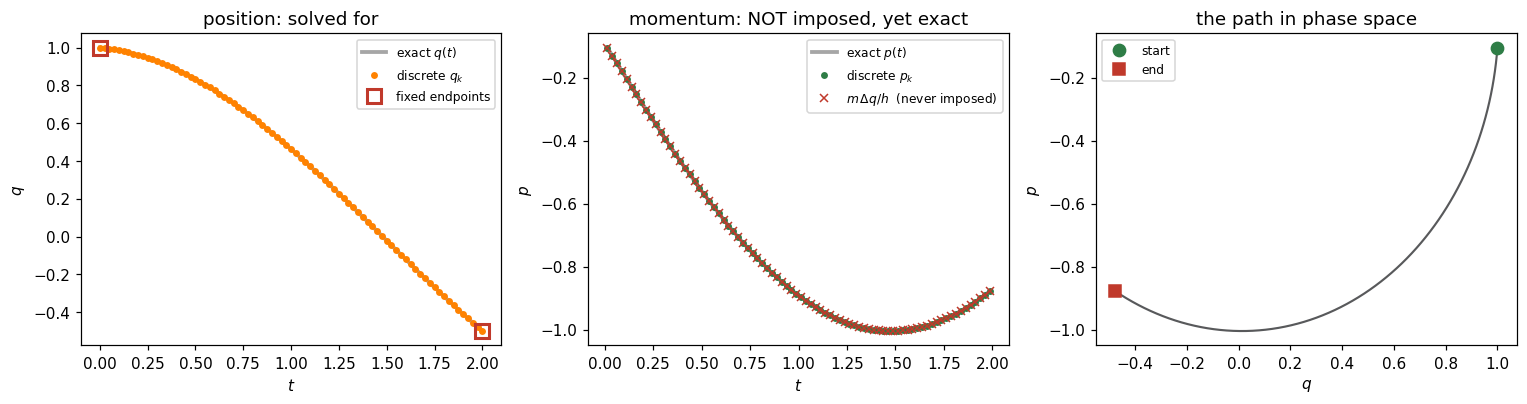

In [4]:
q80, p80, h80 = solve_phase(80)
tn = np.linspace(0.0, T_END, 81)
tm = 0.5*(tn[1:] + tn[:-1])

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))

ax[0].plot(tn, q_exact(tn), 'k-', lw=2.5, alpha=.35, label='exact $q(t)$')
ax[0].plot(tn, q80, 'o', ms=3.5, color='#ff8200', label='discrete $q_k$')
ax[0].plot([0, T_END], [QA, QB], 's', ms=9, mfc='none', mec='#c0392b', mew=2,
           label='fixed endpoints')
ax[0].set_xlabel('$t$'); ax[0].set_ylabel('$q$'); ax[0].legend(fontsize=8)
ax[0].set_title('position: solved for')

ax[1].plot(tm, p_exact(tm), 'k-', lw=2.5, alpha=.35, label='exact $p(t)$')
ax[1].plot(tm, p80, 'o', ms=3.5, color='#2e7d46', label='discrete $p_k$')
ax[1].plot(tm, M_MASS*(q80[1:]-q80[:-1])/h80, 'x', ms=5, color='#c0392b',
           label=r'$m\,\Delta q/h$  (never imposed)')
ax[1].set_xlabel('$t$'); ax[1].set_ylabel('$p$'); ax[1].legend(fontsize=8)
ax[1].set_title('momentum: NOT imposed, yet exact')

ax[2].plot(q80[:-1], p80, '-', color='#58595b', lw=1.4)
ax[2].plot(q80[0], p80[0], 'o', color='#2e7d46', ms=8, label='start')
ax[2].plot(q80[-2], p80[-1], 's', color='#c0392b', ms=8, label='end')
ax[2].set_xlabel('$q$'); ax[2].set_ylabel('$p$'); ax[2].legend(fontsize=8)
ax[2].set_title('the path in phase space')

plt.tight_layout(); plt.show()

## Part 3 — The keystone: **is the stationary point a minimum?**

Now switch to $$q(0)=q(T)=0$$, where the stationary path is exactly
$$q^*\equiv 0$$ and $$p^*\equiv 0$$ — no solver needed, so anything we measure
is a statement about the *second variation* alone.

$$S_N$$ is a quadratic form, so $$S_N[\delta] = \tfrac12\,\delta^{\mathsf T} A\,\delta$$
with a constant Hessian $$A$$. Then:

* **all eigenvalues $$>0$$** → a genuine minimum
* **all eigenvalues $$<0$$** → a maximum
* **mixed signs** → a **saddle**, and the number of negatives is the *index*

Before you run the next cell, commit to a prediction. In Week 4 you found that
the configuration-space action *is* a minimum for $$T<\pi/\omega$$. Here
$$T=1,2,3$$ are all below $$\pi$$. So — minimum?

In [5]:
def hessian_phase(N, T):
    """Hessian of the (h-scaled) phase-space action.  Size (2N-1).

    Scaling by a positive constant cannot change the SIGN of an eigenvalue,
    so the index we count below is a property of S itself.
    """
    h = T/N; nq = N - 1; n = 2*N - 1
    A = np.zeros((n, n))
    for j in range(nq):
        k = j + 1
        A[j, nq+k-1] += 1.0/h
        A[j, nq+k  ] -= 1.0/h
        for l, c in ((k-1, -0.25*M_MASS*OMEGA**2),
                     (k,   -0.50*M_MASS*OMEGA**2),
                     (k+1, -0.25*M_MASS*OMEGA**2)):
            if 1 <= l <= N-1:
                A[j, l-1] += c
    for k in range(N):
        r = nq + k
        if 1 <= k+1 <= N-1: A[r, k  ] += 1.0/h
        if 1 <= k   <= N-1: A[r, k-1] -= 1.0/h
        A[r, nq+k] -= 1.0/M_MASS
    return A


def hessian_config(N, T):
    """Hessian of the Week-4 configuration-space action.  Size (N-1)."""
    h = T/N; n = N - 1
    A = np.zeros((n, n))
    idx = lambda k: None if (k == 0 or k == N) else k - 1
    for k in range(N):                       # loop over cells
        a, b_ = idx(k), idx(k+1)
        for i, si in ((a, -1), (b_, 1)):     # kinetic: (m/h)(q_{k+1}-q_k)^2
            for j, sj in ((a, -1), (b_, 1)):
                if i is not None and j is not None:
                    A[i, j] += (M_MASS/h)*si*sj
        for i in (a, b_):                    # potential: -(h m w^2/4) at midpoint
            for j in (a, b_):
                if i is not None and j is not None:
                    A[i, j] += -(h*M_MASS*OMEGA**2/4.0)
    return A


A_test = hessian_phase(40, 2.0)
print("phase-space Hessian symmetric? ", np.allclose(A_test, A_test.T))

n_neg = lambda A: int((np.linalg.eigvalsh(A) < -1e-9).sum())

N = 80
print(f"\n{'T':>7} {'T/pi':>7} {'dim':>6} {'phase: n_neg':>13} {'config: n_neg':>14}")
for T in [1.0, 2.0, 3.0, 4.0, 7.0, 10.0]:
    print(f"{T:7.2f} {T/np.pi:7.3f} {2*N-1:6d} "
          f"{n_neg(hessian_phase(N, T)):13d} {n_neg(hessian_config(N, T)):14d}")

phase-space Hessian symmetric?  True

      T    T/pi    dim  phase: n_neg  config: n_neg
   1.00   0.318    159            80              0
   2.00   0.637    159            80              0
   3.00   0.955    159            80              0
   4.00   1.273    159            81              1
   7.00   2.228    159            82              2
  10.00   3.183    159            83              3


### What just happened

At $$T=1,2,3$$ the configuration-space action has **zero** negative directions —
a true minimum, exactly as in Week 4. The phase-space action, on the same system
at the same $$T$$, has **80 negative directions out of 159**.

There is no endpoint time at which the phase-space action is a minimum. Roughly
half its directions go downhill, *always*.

Worse: both **pure** directions go downhill. Perturb only $$p$$ (leave $$q$$
alone) and $$S$$ decreases. Perturb only $$q$$ (leave $$p$$ alone) and $$S$$
decreases. Uphill exists only in *correlated* $$(\delta q,\delta p)$$
directions.

pure  dp  direction :  delta^T A delta = -1.000000
pure  dq  direction :  delta^T A delta = -0.993671

eigenvalue range    : [-80.4863, +79.4859]
negative / total    : 80 / 159

=> the form is unbounded BOTH above and below: not a min, not a max.


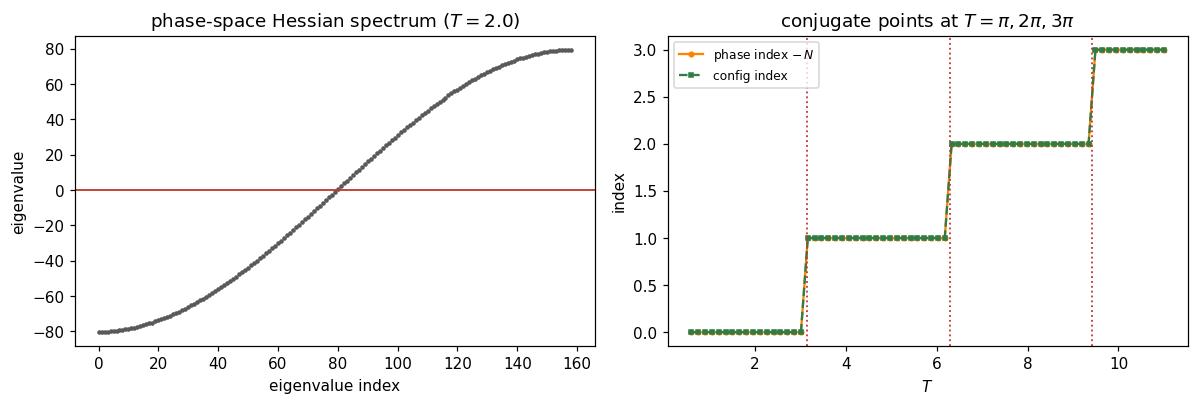

In [6]:
N, T = 80, 2.0
A = hessian_phase(N, T)
ev = np.linalg.eigvalsh(A)

v = np.zeros(2*N-1); v[N-1:] = 1.0/np.sqrt(N)          # vary p only
print(f"pure  dp  direction :  delta^T A delta = {v @ A @ v:+.6f}")
v = np.zeros(2*N-1); v[:N-1] = 1.0/np.sqrt(N-1)        # vary q only
print(f"pure  dq  direction :  delta^T A delta = {v @ A @ v:+.6f}")

print(f"\neigenvalue range    : [{ev.min():+.4f}, {ev.max():+.4f}]")
print(f"negative / total    : {int((ev < -1e-9).sum())} / {len(ev)}")
print("\n=> the form is unbounded BOTH above and below: not a min, not a max.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(np.sort(ev), '.', ms=4, color='#58595b')
ax[0].axhline(0, color='#c0392b', lw=1.2)
ax[0].set_xlabel('eigenvalue index'); ax[0].set_ylabel('eigenvalue')
ax[0].set_title(f'phase-space Hessian spectrum ($T={T}$)')

Ts = np.linspace(0.6, 11.0, 70)
ax[1].plot(Ts, [n_neg(hessian_phase(40, t)) - 40 for t in Ts], 'o-', ms=3,
           color='#ff8200', label=r'phase index $-\,N$')
ax[1].plot(Ts, [n_neg(hessian_config(40, t)) for t in Ts], 's--', ms=3,
           color='#2e7d46', label='config index')
for j in (1, 2, 3):
    ax[1].axvline(j*np.pi, color='#c0392b', ls=':', lw=1.2)
ax[1].set_xlabel('$T$'); ax[1].set_ylabel('index')
ax[1].set_title(r'conjugate points at $T=\pi,2\pi,3\pi$')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Part 4 — The two formulations agree about everything that matters

Subtract $$N$$ (the number of $$p$$ unknowns) from the phase-space index. What
is left should be the configuration-space index — **exactly**, on every grid.

In [7]:
print(f"{'T':>7} {'T/pi':>7} {'phase':>7} {'-N':>6} {'config':>8} {'match':>7}")
N = 80
for T in [1.0, 2.0, 3.0, 3.2, 4.0, 6.0, 6.4, 7.0, 10.0]:
    a = n_neg(hessian_phase(N, T)); b = n_neg(hessian_config(N, T))
    print(f"{T:7.2f} {T/np.pi:7.3f} {a:7d} {a-N:6d} {b:8d} {str(a-N == b):>7}")

print("\ngrid independence -- the index is NOT a discretization artifact:")
for T in (2.0, 7.0):
    for N in (20, 40, 80, 160):
        a = n_neg(hessian_phase(N, T)); b = n_neg(hessian_config(N, T))
        print(f"  T={T:4.1f}  N={N:4d}   phase={a:4d}   phase-N={a-N:2d}   config={b:2d}")

print("\nwhere the index jumps (bisection on the config Hessian, N=160):")
def index_at(T, N=160): return n_neg(hessian_config(N, T))
for target in (1, 2, 3):
    lo, hi = 0.5 + 3.1*(target-1), 3.6*target + 0.6
    while hi - lo > 1e-7:
        mid = 0.5*(lo + hi)
        if index_at(mid) >= target: hi = mid
        else:                       lo = mid
    print(f"  index {target-1} -> {target} at T = {0.5*(lo+hi):.6f}"
          f"   ({target}*pi = {target*np.pi:.6f})")

      T    T/pi   phase     -N   config   match
   1.00   0.318      80      0        0    True
   2.00   0.637      80      0        0    True
   3.00   0.955      80      0        0    True
   3.20   1.019      81      1        1    True
   4.00   1.273      81      1        1    True
   6.00   1.910      81      1        1    True
   6.40   2.037      82      2        2    True
   7.00   2.228      82      2        2    True
  10.00   3.183      83      3        3    True

grid independence -- the index is NOT a discretization artifact:
  T= 2.0  N=  20   phase=  20   phase-N= 0   config= 0
  T= 2.0  N=  40   phase=  40   phase-N= 0   config= 0
  T= 2.0  N=  80   phase=  80   phase-N= 0   config= 0
  T= 2.0  N= 160   phase= 160   phase-N= 0   config= 0
  T= 7.0  N=  20   phase=  22   phase-N= 2   config= 2
  T= 7.0  N=  40   phase=  42   phase-N= 2   config= 2
  T= 7.0  N=  80   phase=  82   phase-N= 2   config= 2
  T= 7.0  N= 160   phase= 162   phase-N= 2   config= 2

where the ind

## What you should have found

| Question | Configuration space $$S[q]$$ | Phase space $$S[q,p]$$ |
|---|---|---|
| Is the true path stationary? | yes | yes |
| Is it a **minimum** for small $$T$$? | **yes** | **no — never** |
| Negative directions at $$T=2$$ | 0 of 79 | **80 of 159** |
| Where does the index jump? | $$T=\pi,2\pi,3\pi$$ | $$T=\pi,2\pi,3\pi$$ |
| Index after subtracting $$N$$ | — | **identical to config** |

**Three conclusions to carry out of the room.**

1. **"Least action" is a misnomer, and not a harmless one.** The true path is
   stationary. In configuration space it happens to be a minimum when
   $$T<\pi/\omega$$; past the first conjugate point it is not. In the phase-space
   formulation — the one Chapters 2 and 5 are built on — it is *never* a minimum,
   at any $$T$$. Scheck's §2.5 title, "A Digression on Variational Principles",
   is doing real work.

2. **This is a Layer-2 weapon.** Ask any AI "does the physical path minimize the
   action?" You will usually get *yes*, frequently defended with
   $$\delta S = 0$$ — a **first**-variation statement offered as proof of a
   **second**-variation claim. You now own a counterexample with numbers in it.

3. **The disagreement is only about minimality.** Both formulations locate the
   same stationary path, assign it the same action, and detect the same
   conjugate points at the same $$T$$. The extra $$N$$ negative directions are
   the $$p$$ degrees of freedom, which stationarity eliminates algebraically.

### Where this goes next

Take the two discrete conditions and eliminate $$p$$ by hand:

$$\frac{q_{k+1}-q_k}{h}=\frac{p_k}{m}
\qquad\Longrightarrow\qquad
m\,\frac{q_{k+1}-2q_k+q_{k-1}}{h^2} \;=\; -\,V'(\bar q)$$

A two-step recurrence in $$q$$ alone — obtained from a **variational principle**,
not from a Taylor expansion of the equation of motion. Notebook 5 asks what
structure an integrator inherits when it is built this way, and what happens to
the energy over ten thousand orbits when it is not.

Write down your prediction **now**, before Notebook 5. That is your Layer-1
entry for the week.

---

*Advanced Mechanics · Fall 2026 · M. Breinig · University of Tennessee, Knoxville*